In [1]:
from upxo.ggrowth.mcgs import mcgs
import numpy as np
import pyvista as pv
from copy import deepcopy
import matplotlib.pyplot as plt

pxt = mcgs(study='independent', input_dashboard='demo_3d_02.xls')
pxt.simulate(verbose=False)

C:\Development\UPXO\upxo_library\src\upxo\interfaces\user_inputs
C:\Development\UPXO\upxo_library\src\upxo\interfaces\user_inputs\demo_3d_02.xls
Algo_hops details
(('300a', 100),)
[False]

 Initiating Monte-Carlo simulation
     xmin, xmax, xinc: 0.0, 60.0, 1.0
     ymin, ymax, yinc: 0.0, 60.0, 1.0
     zmin, zmax, zinc: 0.0, 60.0, 1.0
     No. of states: 16
     Dimensionality: 3
Using ALG-300a
////////////////////////////////
Initiating grain growth
----------------------------------------
GS temporal slice 0 stored
GS temporal slice 1 stored
GS temporal slice 2 stored
GS temporal slice 3 stored
GS temporal slice 4 stored
GS temporal slice 5 stored
GS temporal slice 6 stored
GS temporal slice 7 stored
GS temporal slice 8 stored
GS temporal slice 9 stored
GS temporal slice 10 stored
GS temporal slice 11 stored
GS temporal slice 12 stored
GS temporal slice 13 stored
GS temporal slice 14 stored
GS temporal slice 15 stored
GS temporal slice 16 stored
GS temporal slice 17 stored
GS tempor

In [2]:
tslice = 90
gstslice = pxt.gs[tslice]
gstslice.char_morphology_of_grains(label_str_order=1,
                                   find_grain_voxel_locs=True,
                                   find_spatial_bounds_of_grains=True,
                                   force_compute=True)

---------------------------------------- 
Finding grains.
No. of grains detected = 2294
---------------------------------------- 
Setting PyVista grid.
---------------------------------------- 
Adding scalar field: {sf_name} to PyVista grid self.pvgrid.
Access: self.pvgrid.cell_data['{sf_name}']

Finding voxel locations of grains in lgi.

Finding normal and extended spatial bounds of all grains.
Completed ----------------------------------------
----------------------------------------
---------------------------------------- 
Setting grain volumes (metric: 'volnv') -> 
Grain volumes (metric: 'volnv') -> : have been set.
 ----------------------------------------


In [3]:
gstslice.set_mprops(volnv=True, eqdia=False,
                    eqdia_base_size_spec='volnv',
                    arbbox=False, arbbox_fmt='gid_dict',
                    arellfit=False, arellfit_metric='max',
                    arellfit_calculate_efits=False,
                    arellfit_efit_routine=1,
                    arellfit_efit_regularize_data=False,
                    solidity=False, sol_nan_treatment='replace',
                    sol_inf_treatment='replace',
                    sol_nan_replacement=-1, sol_inf_replacement=-1)

---------------------------------------- 
Setting grain volumes (metric: 'volnv') -> 
Grain volumes (metric: 'volnv') -> : have been set.
 ----------------------------------------


In [4]:
mprops = {'volnv': {'use': True, 'reset': False,
                    'k': [.02, 1.0], 'min_vol': 4,},
          'rat_sanv_volnv': {'use': True, 'reset': False,
                             'k': [0.0, .8], 'sanv_N': 26},}

In [5]:
twspec = {'n': [5, 10, 3],
        'tv': np.array([5, -3.5, 5]),
        'dlk': np.array([1.0, -1.0, 1.0]),
        'dnw': np.array([0.5, 0.5, 0.5]),
        'dno': np.array([0.5, 0.5, 0.5]),
        'tdis': 'normal',
        'tpar': {'loc': 1.12, 'scale': 0.1, 'val': 1},
        'vf': [0.05, 1.00], 'sep_bzcz': False}

In [6]:
twgenspec = {'seedsel': 'random_gb', 'K': 20,
           'bidir_tp': False, 'checks': [True, True],}

In [7]:
gstslice.instantiate_twins(ninstances=2,
                           base_gs_name_prefix='twin.',
                           twin_setup={'nprops': 2, 'mprops': mprops},
                           twspec=twspec,
                           twgenspec=twgenspec,
                           reset_fdb=True, )

################################################## 




 Creating instance: 1 of 2 




 ##################################################
Finding twin host grains.
---------------------------------------- 
Finding grains which can host twins.

   mprops names validation pass.

Calculating grain surface areas (metric: 'sanv').
Set gstslice[90].mprop['sanv'] for gid:229/2294
Set gstslice[90].mprop['sanv'] for gid:458/2294
Set gstslice[90].mprop['sanv'] for gid:687/2294
Set gstslice[90].mprop['sanv'] for gid:916/2294
Set gstslice[90].mprop['sanv'] for gid:1145/2294
Set gstslice[90].mprop['sanv'] for gid:1374/2294
Set gstslice[90].mprop['sanv'] for gid:1603/2294
Set gstslice[90].mprop['sanv'] for gid:1832/2294
Set gstslice[90].mprop['sanv'] for gid:2061/2294
Set gstslice[90].mprop['sanv'] for gid:2290/2294
Finished setting grain surface areas (metric: 'sanv').
rat_sanv_volnv data being set or reset using N={N}

Calculating mprop metric: rat_sanv_volnv

mprops data validation pass.
Caclul

In [8]:
gstslice.mask_fid_and_plot(feature='twins',
                           instance_names=gstslice.fdb.keys(),
                           fid_mask_value=-32,
                           non_fid_mask=True,
                           non_fid_mask_value=-31,
                           write_to_disk=False,
                           write_sparse=True,
                           throw=True,
                           cmap_specs=(['white', 'yellow', 'grey', 'red'], 2),
                           show_edges=False,
                           opacity=1.0, rmax_sp=8, cmax_sp=13,
                           thresholding=True,
                           threshold_value=-32)

Creating pvgrid for instance twin.0: 0 of 2
Creating pvgrid for instance twin.1: 1 of 2
---------------------------------------- 2 ----------------------------------------
rendering 0 of 2 instances
rendering 1 of 2 instances


Widget(value='<iframe src="http://localhost:57725/index.html?ui=P_0x1e199cecec0_0&reconnect=auto" class="pyvis…

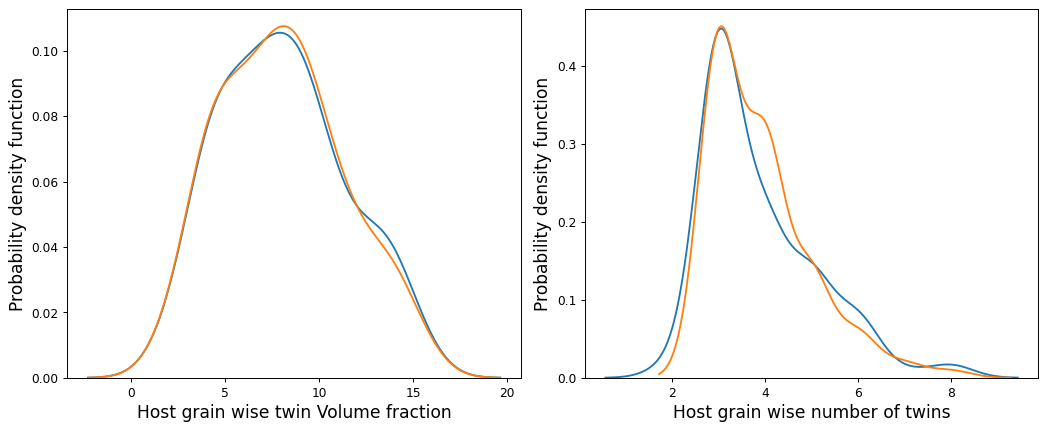

In [9]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import seaborn as sns

total_twin_vol_fr = []
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=88)
for key in gstslice.fdb.keys():
    grain_tvf = gstslice.fdb[key]['data']['twin_vf']

    total_tvf = gstslice.fdb[key]['data']['twin_vf_total']
    total_twin_vol_fr.append(total_tvf)

    ntwins = np.array(list(gstslice.fdb[key]['data']['twin_map_g_nt'].values()))
    ntwins = ntwins[ntwins != 0]

    sns.kdeplot(grain_tvf, ax=axes[0], common_norm=True)
    sns.kdeplot(ntwins, ax=axes[1], common_norm=True)
axes[0].set_xlabel('Host grain wise twin Volume fraction', fontsize=14)
axes[1].set_xlabel('Host grain wise number of twins', fontsize=14)
axes[0].set_ylabel('Probability density function', fontsize=14)
axes[1].set_ylabel('Probability density function', fontsize=14)
plt.tight_layout()
plt.show()

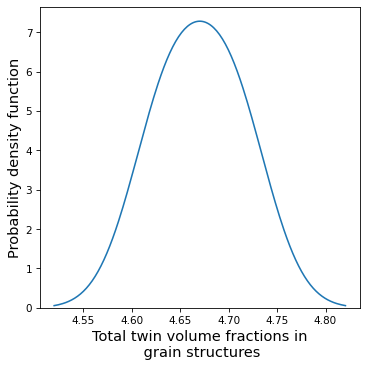

In [10]:
plt.figure(figsize=(5, 5), dpi=75)
sns.kdeplot(total_twin_vol_fr, common_norm=True)
plt.xlabel('Total twin volume fractions in\n grain structures', fontsize=14)
plt.ylabel('Probability density function', fontsize=14)
plt.tight_layout()
plt.show()